In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow gensim pandas numpy scikit-learn -q

import os
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

PREPROCESSED_PATH = "/content/drive/MyDrive/dataset_preprocessed.csv"
MODEL_DIR         = "/content/drive/MyDrive/fake_news_models"
PLOTS_DIR         = "/content/drive/MyDrive/news_plots"
WORD2VEC_PATH     = os.path.join(MODEL_DIR, "word2vec_model.model")
EMBEDDING_LABELS_PATH = os.path.join(MODEL_DIR, "embedding_labels.npy")
LSTM_MODEL_PATH   = os.path.join(MODEL_DIR, "lstm_w2v.keras")
LSTM_TOKENIZER_PATH = os.path.join(MODEL_DIR, "lstm_tokenizer.pkl")
LSTM_MAXLEN_PATH  = os.path.join(MODEL_DIR, "lstm_maxlen.pkl")
X_TEST_LSTM_PATH  = os.path.join(MODEL_DIR, "X_test_lstm.npy")
Y_TEST_LSTM_PATH  = os.path.join(MODEL_DIR, "y_test_lstm.npy")
PLOT_LSTM_CURVES  = os.path.join(PLOTS_DIR, "lstm_w2v_curves.png")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.6 MB/s eta 0:00:00


In [3]:
VOCAB_SIZE = 20_000
MAX_LEN    = 300
EMBED_DIM  = 100
BATCH_SIZE = 64
EPOCHS     = 10

tf.random.set_seed(42)
np.random.seed(42)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
print("Setup complete!")

Setup complete!


In [4]:
print("Loading preprocessed dataset")
df = pd.read_csv(PREPROCESSED_PATH)

def parse_tokens(val):
    if isinstance(val, list): return val
    if isinstance(val, str):
        try: return ast.literal_eval(val)
        except: return val.split()
    return []

Loading preprocessed dataset


In [5]:
df

,title,text,unreliable,author,word_count,char_length,preprocessingText2,cleanText
0,WARNING: A Pivotal Moment For The Stock Market...,WARNING: A Pivotal Moment For The Stock Market...,1,Anonymous Coward (UID 72071746),43,228,"['warn', 'pivotal', 'moment', 'stock', 'market...",warn pivotal moment stock market may page mail...
1,"Trump, top defense officials, discuss North Ko...",WASHINGTON - U.S. President Donald Trump met ...,0,Unknown,85,426,"['washington', 'u', 'president', 'donald', 'tr...",washington u president donald trump meet tuesd...
2,British civil servants' union calls nationwide...,LONDON - British civil servants will vote nex...,0,Unknown,304,1491,"['london', 'british', 'civil', 'servant', 'vot...",london british civil servant vote next month n...
3,A**hole Of The Day – Michele Bachmann: Muslim...,Michele Bachmann has been pretty quiet since l...,1,Unknown,633,2980,"['michele', 'bachmann', 'pretty', 'quiet', 'si...",michele bachmann pretty quiet since leave offi...
4,’Deport Fat People’ Posters Appear At CU Bould...,Posters calling on Donald Trump to “Deport Fat...,0,Lucas Nolan,123,578,"['poster', 'call', 'donald', 'trump', 'deport'...",poster call donald trump deport fat people app...
...,...,...,...,...,...,...,...,...
58412,"Pierre Berge, who co-founded Yves Saint Lauren...",PARIS - French businessman and art patron Pie...,0,Unknown,185,926,"['paris', 'french', 'businessman', 'art', 'pat...",paris french businessman art patron pierre ber...
58413,Burundi opposition platform boycotts new round...,NAIROBI - Burundi s main opposition grouping ...,0,Unknown,271,1441,"['nairobi', 'burundi', 'main', 'opposition', '...",nairobi burundi main opposition grouping say b...
58414,Hillary’s Message To Former Miss Universe Cal...,Miss Universe 1996 Alicia Machado is now an Am...,1,Unknown,246,1172,"['miss', 'universe', 'alicia', 'machado', 'ame...",miss universe alicia machado american citizen ...
58415,Swedish Library Bans Factual Book on Immigrati...,A library in Sweden’s capital is refusing to s...,0,Virginia Hale,377,2045,"['library', 'sweden', 'capital', 'refuse', 'st...",library sweden capital refuse stock kurdish ec...


In [6]:
df["preprocessingText2"] = df["preprocessingText2"].apply(parse_tokens)
df["cleanText"] = df["preprocessingText2"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

labels = np.load(EMBEDDING_LABELS_PATH, allow_pickle=True)
texts  = df["cleanText"].tolist()

X_train_raw, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30,  random_state=42, stratify=labels
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp,  test_size=0.50,  random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

Train: 40891 | Val: 8763 | Test: 8763


In [7]:
if os.path.exists(LSTM_TOKENIZER_PATH):
    print("Loading existing tokenizer...")
    with open(LSTM_TOKENIZER_PATH, "rb") as f:
        tokenizer = pickle.load(f)
else:
    print("Fitting tokenizer...")
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train_raw)
    with open(LSTM_TOKENIZER_PATH, "wb") as f:
        pickle.dump(tokenizer, f)
    with open(LSTM_MAXLEN_PATH, "wb") as f:
        pickle.dump(MAX_LEN, f)
    print("Saved tokenizer to Drive!")


Fitting tokenizer...
Saved tokenizer to Drive!


In [8]:
def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = encode(X_train_raw)
X_val   = encode(X_val_raw)
X_test  = encode(X_test_raw)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (40891, 300) | Val: (8763, 300) | Test: (8763, 300)


In [9]:
w2v_model        = Word2Vec.load(WORD2VEC_PATH)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits = 0
for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE: continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1

coverage = hits / min(len(tokenizer.word_index), VOCAB_SIZE)
print(f"Word2Vec coverage: {hits}/{min(len(tokenizer.word_index), VOCAB_SIZE)} ({coverage*100:.1f}%)")

Word2Vec coverage: 19988/20000 (99.9%)


In [10]:
if os.path.exists(LSTM_MODEL_PATH):
    print("Loading existing LSTM model...")
    model = tf.keras.models.load_model(LSTM_MODEL_PATH)
else:
    print("Building and training LSTM model...")
    model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,weights=[embedding_matrix],input_length=MAX_LEN,trainable=True),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="LSTM_Word2Vec")

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ]
    )

    model.save(LSTM_MODEL_PATH)
    np.save(X_TEST_LSTM_PATH, X_test)
    np.save(Y_TEST_LSTM_PATH, y_test)
    print("Saved LSTM model, X_test, y_test to Drive!")

    if not os.path.exists(PLOT_LSTM_CURVES):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, metric, title in zip(axes, ["loss","accuracy"], ["Loss","Accuracy"]):
            ax.plot(history.history[metric],           label="Train")
            ax.plot(history.history[f"val_{metric}"],  label="Val", linestyle="--")
            ax.set_title(f"LSTM (Word2Vec) — {title}")
            ax.set_xlabel("Epoch")
            ax.legend()
        plt.tight_layout()
        plt.savefig(PLOT_LSTM_CURVES, dpi=150)
        plt.show()
        print("Saved:", PLOT_LSTM_CURVES)

    print("Best val accuracy:", f"{max(history.history['val_accuracy']):.4f}")

print("\nLSTM model saved to Drive ")

Building and training LSTM model...


Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9199 - loss: 0.2042 - val_accuracy: 0.9558 - val_loss: 0.1235
Epoch 2/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.9560 - loss: 0.1166 - val_accuracy: 0.9581 - val_loss: 0.1090
Epoch 3/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9743 - loss: 0.0705 - val_accuracy: 0.9651 - val_loss: 0.1021
Epoch 4/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.9859 - loss: 0.0421 - val_accuracy: 0.9633 - val_loss: 0.1252
Epoch 5/10
639/639 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - accuracy: 0.9928 - loss: 0.0233 - val_accuracy: 0.9679 - val_loss: 0.1105
Saved LSTM model, X_test, y_test to Drive!
Best val accuracy: 0.9679

LSTM model saved to Drive 


137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

 Test Accuracy: 0.9649 (96.49%)

 Classification Report:
              precision    recall  f1-score   support

        Real       0.96      0.97      0.97      4737
        Fake       0.97      0.96      0.96      4026

    accuracy                           0.96      8763
   macro avg       0.97      0.96      0.96      8763
weighted avg       0.96      0.96      0.96      8763



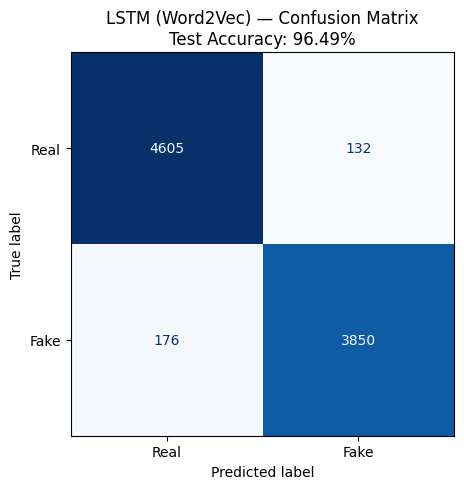

Saved confusion matrix to Drive!


In [11]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

X_test_eval = np.load(X_TEST_LSTM_PATH)
y_test_eval  = np.load(Y_TEST_LSTM_PATH)

y_prob = model.predict(X_test_eval, batch_size=64)
y_pred = (y_prob >= 0.5).astype(int).flatten()
test_acc = accuracy_score(y_test_eval, y_pred)
print(f"\n Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


print("\n Classification Report:")
print(classification_report(y_test_eval, y_pred, target_names=["Real", "Fake"]))

cm = confusion_matrix(y_test_eval, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"LSTM (Word2Vec) — Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "lstm_w2v_confusion.png"), dpi=150)
plt.show()
print("Saved confusion matrix to Drive!")